In [137]:
import requests
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import statsmodels.api as sm
from datetime import datetime, timedelta
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import json

In [166]:
raw_total_df = pd.read_csv('test.csv').drop(columns='Unnamed: 0')
raw_total_df.columns

Index(['Datetime', 'Hourly SR (wh/m^2)', 'Day/Night', 'Dates', 'Time', 'temp',
       'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'preciptype',
       'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir', 'cloudcover',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'conditions',
       'Sun Angle'],
      dtype='object')

In [175]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def prepare_data_and_train_models(df):
    # Filter the data by date
    train_df = df[df['Dates'] != '2024-07-01']
    test_df = df[df['Dates'] == '2024-07-01']

    # Assuming all columns except 'Hourly SR (wh/m^2)' are features
    # features = df.columns.drop(['Day/Night', 'Datetime', 'Dates', 'Time', 'solarradiation', 'Hourly SR (wh/m^2)', 'preciptype', 'conditions', 'precipprob'])  # Adjust as necessary
    
    features = ['temp', 'cloudcover', 'uvindex']
    
    X_train = train_df[features]
    y_train = train_df['Hourly SR (wh/m^2)']
    X_test = test_df[features]
    y_test = test_df['Hourly SR (wh/m^2)']

    # Define a dictionary of models
    models = {
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
        'Linear Regression': make_pipeline(StandardScaler(), LinearRegression())
    }

    best_model = None
    lowest_mse = float('inf')

    # Train and evaluate each model
    for name, model in models.items():
        model.fit(X_train, y_train)  # Train model
        y_pred = model.predict(X_test)  # Predict on test set
        mse = mean_squared_error(y_test, y_pred)  # Calculate MSE
        print(f'{name} Mean Squared Error: {mse}')

        # Check if the current model has the lowest MSE
        if mse < lowest_mse:
            lowest_mse = mse
            best_model = model

    return best_model

# Example usage
# Assuming 'raw_total_df' is your DataFrame
best_model = prepare_data_and_train_models(raw_total_df)
print("Best Model:", type(best_model).__name__)


Random Forest Mean Squared Error: 3083.4907617039403
Gradient Boosting Mean Squared Error: 2777.465751349302
Linear Regression Mean Squared Error: 1726.7329342277346
Best Model: Pipeline


/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_74310/696755203.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Time'] = pd.to_datetime(test_df['Time'], format='%H:%M:%S')  # Adjust format as necessary


[ 37.48391701  36.76947236  39.38909757  35.92612185  32.90885429
  33.40262826  35.79721598  59.43295289  61.28570084  82.73659595
 130.6045333  257.7345221  206.17857155  91.29025786 235.51674973
 237.54646935 209.04071694 186.59134914  53.97292779  48.92594061
  46.59034344  39.52456138  34.79437649  34.98227291]


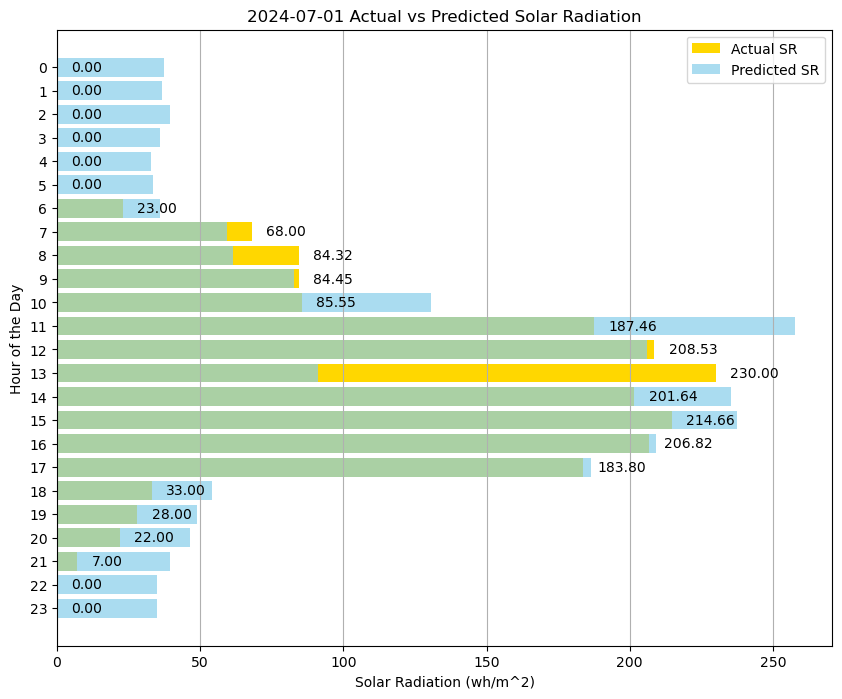

In [176]:
def plot_predictions_vs_actual(df, model, date='2024-07-01'):
    # Filter the data for the specified date
    test_df = df[df['Dates'] == date]
    
    # Ensure 'Time' is converted to datetime type for hour extraction
    if not pd.api.types.is_datetime64_any_dtype(test_df['Time']):
        test_df['Time'] = pd.to_datetime(test_df['Time'], format='%H:%M:%S')  # Adjust format as necessary

    # Extract features
    features = ['temp', 'cloudcover', 'uvindex']
    X_test = test_df[features]
    y_test = test_df['Hourly SR (wh/m^2)']

    # Predict using the best model
    y_pred = model.predict(X_test)
    print(y_pred)

    # Plotting
    plt.figure(figsize=(10, 8))
    # Create bars for actual values
    actual_bars = plt.barh(test_df['Time'].dt.hour, y_test, color='gold', label='Actual SR')
    # Create bars for predicted values
    pred_bars = plt.barh(test_df['Time'].dt.hour, y_pred, color='skyblue', alpha=0.7, label='Predicted SR')
    
    plt.title(f'{date} Actual vs Predicted Solar Radiation')
    plt.xlabel('Solar Radiation (wh/m^2)')
    plt.ylabel('Hour of the Day')
    plt.yticks(test_df['Time'].dt.hour)
    plt.gca().invert_yaxis()
    plt.legend()
    plt.grid(True, axis='x')
    
    # Adding text labels on bars for actual values
    for bar in actual_bars:
        plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left')

    plt.show()

# Example usage, assuming 'best_model' from previous model selection
plot_predictions_vs_actual(raw_total_df, best_model)


In [138]:
raw_total_df = pd.read_csv('test.csv').drop(columns='Unnamed: 0')
# df = pd.get_dummies(raw_total_df, columns=['Day/Night', 'conditions'], drop_first=True)

# Separate features and target variable
X = raw_total_df.drop(columns=['Day/Night', 'Datetime', 'Dates', 'Time', 'solarradiation', 'Hourly SR (wh/m^2)', 'preciptype', 'conditions', 'precipprob'])
y = raw_total_df['Hourly SR (wh/m^2)']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X

,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,cloudcover,solarenergy,uvindex,severerisk,Sun Angle
0,9.0,9.0,2.7,64.70,0.0,0.0,0.0,14.4,3.6,52.0,2.0,0.0,0.0,10.0,-7.862163
1,9.2,8.9,-0.1,52.09,0.0,0.0,0.0,17.3,4.9,72.0,0.0,0.0,0.0,10.0,-15.930717
2,8.9,8.9,1.3,58.81,0.0,0.0,0.0,15.8,3.4,74.0,2.0,0.0,0.0,10.0,-22.525003
3,9.4,9.4,0.3,52.94,0.0,0.0,0.0,15.8,4.6,51.0,0.0,0.2,1.0,10.0,-27.079349
4,10.6,10.6,0.8,50.72,0.0,0.0,0.0,20.2,7.8,51.0,3.0,0.7,2.0,10.0,-29.076118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1662,19.6,19.6,11.6,59.73,0.0,0.0,0.0,12.2,2.5,218.0,2.0,0.1,0.0,10.0,60.138678
1663,19.1,19.1,10.7,58.39,0.0,0.0,0.0,12.2,0.7,32.0,3.0,0.1,0.0,10.0,63.651782
1664,17.7,17.7,9.9,60.27,0.0,0.0,0.0,12.2,3.3,2.0,3.0,0.0,0.0,10.0,62.146866
1665,16.8,16.8,9.8,63.37,0.0,0.0,0.0,11.9,3.5,46.0,2.0,0.0,0.0,10.0,56.320541


### RandomForest Regression

In [143]:
# RandomForest Regression
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
rf_mse = mean_squared_error(y_test, y_pred)
rf_r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {rf_mse}')
print(f'R^2 Score: {rf_r2}')

Mean Squared Error: 1819.7739093381442
R^2 Score: 0.7282610509116392


### Linear Regression

In [4]:
from sklearn.linear_model import LinearRegression

# Initialize the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Predict on the test set
y_pred = linear_model.predict(X_test)

# Evaluate the model
ln_mse = mean_squared_error(y_test, y_pred)
ln_r2 = r2_score(y_test, y_pred)

print(f'Linear Regression Mean Squared Error: {ln_mse}')
print(f'Linear Regression R² Score: {ln_r2}')

Linear Regression Mean Squared Error: 2731.137615405892
Linear Regression R² Score: 0.5921710594828711


### GradientBoosting Regression

In [136]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the model
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predict on the test set
y_pred = gb_model.predict(X_test)

# Evaluate the model
gb_mse = mean_squared_error(y_test, y_pred)
gb_r2 = r2_score(y_test, y_pred)

print(f'Gradient Boosting Mean Squared Error: {gb_mse}')
print(f'Gradient Boosting R² Score: {gb_r2}')

Gradient Boosting Mean Squared Error: 1702.4622377732799
Gradient Boosting R² Score: 0.7457786942756048


### SVR Regression

In [48]:
from sklearn.svm import SVR

# Initialize the model
svr_model = SVR(kernel='rbf', C=100, gamma=0.1)

# Train the model
svr_model.fit(X_train, y_train)

# Predict on the test set
y_pred = svr_model.predict(X_test)

# Evaluate the model
svr_mse = mean_squared_error(y_test, y_pred)
svr_r2 = r2_score(y_test, y_pred)

print(f'Support Vector Regression Mean Squared Error: {svr_mse}')
print(f'Support Vector Regression R² Score: {svr_r2}')

Support Vector Regression Mean Squared Error: 2492.9839285041626
Support Vector Regression R² Score: 0.627733517142093


### LGB Regression

In [7]:
import lightgbm as lgb

# Initialize the model
lgb_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=-1, random_state=42)

# Train the model
lgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred = lgb_model.predict(X_test)

# Evaluate the model
lgb_mse = mean_squared_error(y_test, y_pred)
lgb_r2 = r2_score(y_test, y_pred)

print(f'LightGBM Mean Squared Error: {lgb_mse}')
print(f'LightGBM R² Score: {lgb_r2}')

### Neural Network

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Initialize the model
nn_model = Sequential()
nn_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
nn_model.add(Dense(32, activation='relu'))
nn_model.add(Dense(1))

# Compile the model
nn_model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
nn_model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Predict on the test set
y_pred = nn_model.predict(X_test)

# Evaluate the model
nn_mse = mean_squared_error(y_test, y_pred)
nn_r2 = r2_score(y_test, y_pred)

print(f'Neural Network Mean Squared Error: {nn_mse}')
print(f'Neural Network R² Score: {nn_r2}')


2024-07-02 14:26:11.167916: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/100
34/34 [==============================] - 0s 4ms/step - loss: 13556.8525 - val_loss: 12726.3281
Epoch 2/100
34/34 [==============================] - 0s 1ms/step - loss: 12635.7559 - val_loss: 11399.8359
Epoch 3/100
34/34 [==============================] - 0s 1ms/step - loss: 10556.7852 - val_loss: 8484.2510
Epoch 4/100
34/34 [==============================] - 0s 2ms/step - loss: 7132.6782 - val_loss: 4918.6494
Epoch 5/100
34/34 [==============================] - 0s 1ms/step - loss: 4201.0615 - val_loss: 3160.2478
Epoch 6/100
34/34 [==============================] - 0s 1ms/step - loss: 3310.8035 - val_loss: 2877.4153
Epoch 7/100
34/34 [==============================] - 0s 1ms/step - loss: 3147.3130 - val_loss: 2744.0178
Epoch 8/100
34/34 [==============================] - 0s 1ms/step - loss: 3035.9771 - val_loss: 2646.7808
Epoch 9/100
34/34 [==============================] - 0s 1ms/step - loss: 2947.8811 - val_loss: 2591.2161
Epoch 10/100
34/34 [==============================

### XGB Regression

In [3]:
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

In [124]:
# function to get tmr's weather
tmr_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/tomorrow?unitGroup=metric&key=HJ2JWKPKSPZKWD64FVT9F7A6Z&contentType=json"

def get_tmr_weather_df():
    # URL setup for tomorrow's weather data
    tmr_date = datetime.now() + timedelta(days=1)
    tmr_response = requests.get(tmr_url)

    # Check if the request was successful
    if tmr_response.status_code == 200:
        # Parse the JSON data
        weather_data = tmr_response.json()
        print("Data retrieved successfully!")
        
        # File path setup for saving the data
        tmr_file_path = f"{tmr_date.strftime('%Y-%m-%d')}_weather_data.json"
        with open(tmr_file_path, 'w') as f:
            json.dump(weather_data, f, indent=4)
        print("Weather data saved successfully!")
        
        # Load and parse the JSON data into a DataFrame
        with open(tmr_file_path, 'r') as file:
            tmr_json_data = json.load(file)
        
        # Initialize an empty list to hold all hourly data
        tmr_hourly_data = []
        
        # Loop through each day in the data
        for day in tmr_json_data['days']:
            # Extract each 'hour' from 'hours' array and enrich it with 'day' level data
            for hour in day['hours']:
                hour.update({
                    'date': day['datetime'],
                    'tempmax': day['tempmax'],
                    'tempmin': day['tempmin'],
                    'feelslikemax': day['feelslikemax'],
                    'feelslikemin': day['feelslikemin'],
                    'sunrise': day['sunrise'],
                    'sunset': day['sunset'],
                    'moonphase': day['moonphase'],
                    'conditions': day['conditions'],
                    'description': day['description'],
                    'icon': day['icon']
                })
                tmr_hourly_data.append(hour)
        
        # Create a DataFrame from the hourly data
        tmr_hourly_df = pd.DataFrame(tmr_hourly_data)
        
        # Define the columns of interest
        columns_of_interest = [
            'date', 'datetime', 'temp', 'tempmax', 'tempmin', 'feelslike', 'feelslikemax', 'feelslikemin', 
            'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'preciptype', 'snow', 'snowdepth',
            'windgust', 'windspeed', 'winddir', 'pressure', 'cloudcover', 'visibility', 
            'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise', 'sunset', 
            'moonphase', 'conditions', 'description', 'icon'
        ]

        
        # Reindex and rename the DataFrame
        tmr_hourly_df = tmr_hourly_df.reindex(columns=columns_of_interest).rename(columns={"date": "Dates", "datetime": "Time"})
        latitude = 49.2827

        def get_declination(day_of_year):
            return 23.45 * np.sin(np.deg2rad(360 * (284 + day_of_year) / 365))

        def get_hour_angle(time, longitude):
            total_hours = time.hour + time.minute / 60 + time.second / 3600
            solar_noon = 12 - (longitude / 15)
            return 15 * (total_hours - solar_noon)

        def solar_elevation(latitude, declination, hour_angle):
            latitude_rad = np.deg2rad(latitude)
            declination_rad = np.deg2rad(declination)
            hour_angle_rad = np.deg2rad(hour_angle)
            elevation_rad = np.arcsin(np.sin(latitude_rad) * np.sin(declination_rad) +
                                    np.cos(latitude_rad) * np.cos(declination_rad) * np.cos(hour_angle_rad))
            return np.rad2deg(elevation_rad)

        tmr_hourly_df['Time'] = pd.to_datetime(tmr_hourly_df['Time'])
        tmr_hourly_df['Sun Angle'] = tmr_hourly_df['Time'].apply(
            lambda x: solar_elevation(
                latitude,
                get_declination(x.timetuple().tm_yday),
                get_hour_angle(x, longitude=-123.1207)
            )
        )
        
        return tmr_hourly_df
    else:
        print("Failed to retrieve data:", tmr_response.status_code)
        return None

# Example usage
tmr_weather_df = get_tmr_weather_df()
tmr_weather_df.shape

Data retrieved successfully!
Weather data saved successfully!


/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_74310/1002799182.py:80: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tmr_hourly_df['Time'] = pd.to_datetime(tmr_hourly_df['Time'])


(24, 33)

In [148]:
# function to get today's weather
yst_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/yesterday?unitGroup=metric&key=FLBEV2T2WUAPQGP2MP25GFASV&contentType=json"

def get_today_weather_df():
    # URL setup for tomorrow's weather data
    today_date = datetime.now()
    today_response = requests.get(yst_url)

    # Check if the request was successful
    if today_response.status_code == 200:
        # Parse the JSON data
        weather_data = today_response.json()
        print("Data retrieved successfully!")
        
        # File path setup for saving the data
        today_file_path = f"{today_date.strftime('%Y-%m-%d')}_weather_data.json"
        with open(today_file_path, 'w') as f:
            json.dump(weather_data, f, indent=4)
        print("Weather data saved successfully!")
        
        # Load and parse the JSON data into a DataFrame
        with open(today_file_path, 'r') as file:
            today_json_data = json.load(file)
        
        # Initialize an empty list to hold all hourly data
        today_hourly_data = []
        
        # Loop through each day in the data
        for day in today_json_data['days']:
            # Extract each 'hour' from 'hours' array and enrich it with 'day' level data
            for hour in day['hours']:
                hour.update({
                    'date': day['datetime'],
                    'tempmax': day['tempmax'],
                    'tempmin': day['tempmin'],
                    'feelslikemax': day['feelslikemax'],
                    'feelslikemin': day['feelslikemin'],
                    'sunrise': day['sunrise'],
                    'sunset': day['sunset'],
                    'moonphase': day['moonphase'],
                    'conditions': day['conditions'],
                    'description': day['description'],
                    'icon': day['icon']
                })
                today_hourly_data.append(hour)
        
        # Create a DataFrame from the hourly data
        today_hourly_df = pd.DataFrame(today_hourly_data)
        
        # Define the columns of interest
        columns_of_interest = [
            'date', 'datetime', 'temp', 'tempmax', 'tempmin', 'feelslike', 'feelslikemax', 'feelslikemin', 
            'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'preciptype', 'snow', 'snowdepth',
            'windgust', 'windspeed', 'winddir', 'pressure', 'cloudcover', 'visibility', 
            'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise', 'sunset', 
            'moonphase', 'conditions', 'description', 'icon'
        ]

        
        # Reindex and rename the DataFrame
        today_hourly_df = today_hourly_df.reindex(columns=columns_of_interest).rename(columns={"date": "Dates", "datetime": "Time"})
        latitude = 49.2827

        def get_declination(day_of_year):
            return 23.45 * np.sin(np.deg2rad(360 * (284 + day_of_year) / 365))

        def get_hour_angle(time, longitude):
            total_hours = time.hour + time.minute / 60 + time.second / 3600
            solar_noon = 12 - (longitude / 15)
            return 15 * (total_hours - solar_noon)

        def solar_elevation(latitude, declination, hour_angle):
            latitude_rad = np.deg2rad(latitude)
            declination_rad = np.deg2rad(declination)
            hour_angle_rad = np.deg2rad(hour_angle)
            elevation_rad = np.arcsin(np.sin(latitude_rad) * np.sin(declination_rad) +
                                    np.cos(latitude_rad) * np.cos(declination_rad) * np.cos(hour_angle_rad))
            return np.rad2deg(elevation_rad)

        today_hourly_df['Time'] = pd.to_datetime(today_hourly_df['Time'])
        today_hourly_df['Sun Angle'] = today_hourly_df['Time'].apply(
            lambda x: solar_elevation(
                latitude,
                get_declination(x.timetuple().tm_yday),
                get_hour_angle(x, longitude=-123.1207)
            )
        )
        
        return today_hourly_df
    else:
        print("Failed to retrieve data:", today_response.status_code)
        return None

# Example usage
today_weather_df = get_today_weather_df()
today_weather_df

Data retrieved successfully!
Weather data saved successfully!


/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_74310/4172692122.py:80: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  today_hourly_df['Time'] = pd.to_datetime(today_hourly_df['Time'])


,Dates,Time,temp,tempmax,tempmin,feelslike,feelslikemax,feelslikemin,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,Sun Angle
0,2024-07-02,2024-07-03 00:00:00,15.0,20.2,12.8,15.0,20.2,12.8,8.9,66.48,...,0.0,0.0,10.0,05:12:23,21:20:46,0.89,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,38.546631
1,2024-07-02,2024-07-03 01:00:00,14.8,20.2,12.8,14.8,20.2,12.8,9.4,69.94,...,0.0,0.0,10.0,05:12:23,21:20:46,0.89,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,28.795980
2,2024-07-02,2024-07-03 02:00:00,13.9,20.2,12.8,13.9,20.2,12.8,9.8,76.32,...,0.0,0.0,10.0,05:12:23,21:20:46,0.89,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,19.116813
3,2024-07-02,2024-07-03 03:00:00,13.3,20.2,12.8,13.3,20.2,12.8,9.3,76.85,...,0.0,0.0,10.0,05:12:23,21:20:46,0.89,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,9.849953
4,2024-07-02,2024-07-03 04:00:00,12.8,20.2,12.8,12.8,20.2,12.8,9.4,79.78,...,0.0,0.0,10.0,05:12:23,21:20:46,0.89,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,1.322080
5,2024-07-02,2024-07-03 05:00:00,13.0,20.2,12.8,13.0,20.2,12.8,9.9,82.00,...,0.0,0.0,10.0,05:12:23,21:20:46,0.89,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,-6.108239
6,2024-07-02,2024-07-03 06:00:00,13.0,20.2,12.8,13.0,20.2,12.8,9.9,82.00,...,0.1,0.0,10.0,05:12:23,21:20:46,0.89,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,-12.037191
7,2024-07-02,2024-07-03 07:00:00,13.7,20.2,12.8,13.7,20.2,12.8,10.0,77.98,...,0.4,1.0,10.0,05:12:23,21:20:46,0.89,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,-16.044586
8,2024-07-02,2024-07-03 08:00:00,14.4,20.2,12.8,14.4,20.2,12.8,10.0,74.81,...,0.5,1.0,10.0,05:12:23,21:20:46,0.89,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,-17.776223
9,2024-07-02,2024-07-03 09:00:00,15.7,20.2,12.8,15.7,20.2,12.8,10.5,71.07,...,0.8,2.0,10.0,05:12:23,21:20:46,0.89,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,-17.056862


In [155]:
tmr_weather_df = tmr_weather_df[['Dates', 'temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'snow',
       'snowdepth', 'windgust', 'windspeed', 'winddir', 'cloudcover',
       'solarenergy', 'uvindex', 'severerisk', 'Sun Angle']]
tmr_weather_df

KeyError: "['Dates'] not in index"

In [156]:
def predict_solar_radiation(weather_df, scaler, model):
    # Selecting necessary columns
    date_name = weather_df['Dates'][0]
    weather_df = weather_df[['temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'snow',
                             'snowdepth', 'windgust', 'windspeed', 'winddir', 'cloudcover',
                             'solarenergy', 'uvindex', 'severerisk', 'Sun Angle']]
    
    # Scaling the data
    weather_df_scaled = scaler.transform(weather_df)
    
    # Making predictions
    predictions = model.predict(weather_df_scaled)
    
    # Creating DataFrame for predictions
    predictions_df = pd.DataFrame({
        'Hour': range(len(predictions)), 
        'Predicted Solar Radiation (wh/m^2)': predictions
    })
    
    # Filtering hours from 6 AM to 9 PM
    filtered_predictions = predictions_df[(predictions_df['Hour'] >= 6) & (predictions_df['Hour'] <= 21)]

    # Plotting
    plt.figure(figsize=(10, 8))
    bars = plt.barh(filtered_predictions['Hour'], filtered_predictions['Predicted Solar Radiation (wh/m^2)'], color='skyblue')
    plt.title(f'Predicted Solar Radiation for {date_name}')
    plt.xlabel('Predicted Solar Radiation (wh/m^2)')
    plt.ylabel('Hour of the Day')
    plt.yticks(filtered_predictions['Hour'])
    plt.gca().invert_yaxis()
    plt.grid(True, axis='x')
    
    # Adding text labels on bars
    for bar in bars:
        plt.text(
            bar.get_width() + 5,  # x-coordinate
            bar.get_y() + bar.get_height() / 2,  # y-coordinate
            f'{bar.get_width():.2f}',  # Text to display
            va='center',  # Vertical alignment
            ha='left'  # Horizontal alignment
        )

    plt.show()

In [157]:
predict_solar_radiation(tmr_weather_df, scaler, gb_model)

KeyError: 'Dates'

In [111]:
tmr_weather_df = tmr_weather_df[['temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'snow',
       'snowdepth', 'windgust', 'windspeed', 'winddir', 'cloudcover',
       'solarenergy', 'uvindex', 'severerisk', 'Sun Angle']]

In [112]:
tomorrow_df_scaled = scaler.transform(tmr_weather_df)
tomorrow_predictions = gb_model.predict(tomorrow_df_scaled)

predictions_df = pd.DataFrame({'Hour': range(len(tomorrow_predictions)), 'Predicted Solar Radiation (wh/m^2)': tomorrow_predictions})

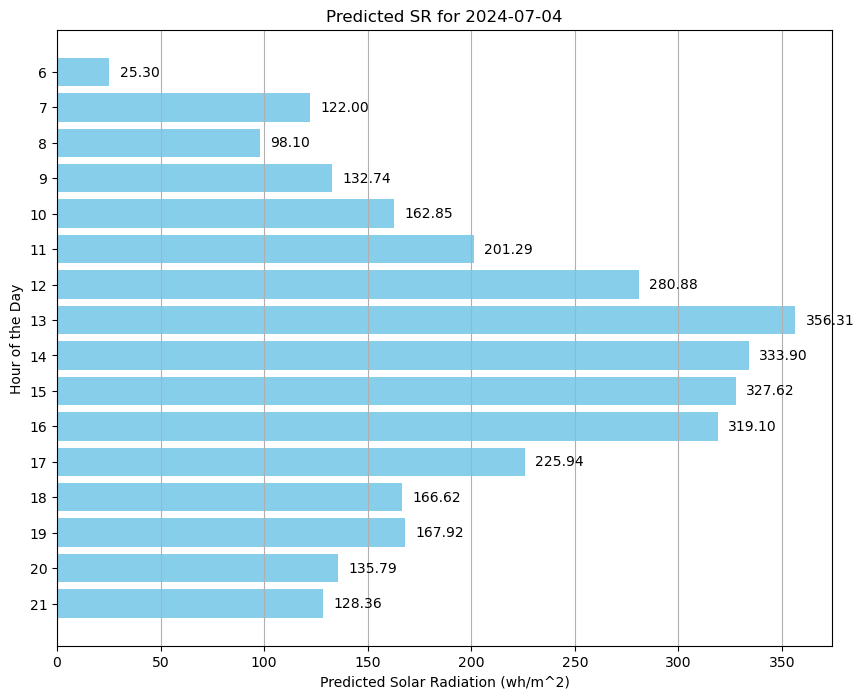

In [141]:
filtered_predictions = predictions_df[(predictions_df['Hour'] >= 6) & (predictions_df['Hour'] <= 21)].sort_values('Hour',ascending=True)
tmr_date = str(datetime.now() + timedelta(days=1))[0:10]
plt.figure(figsize=(10, 8))
plt.barh(filtered_predictions['Hour'], filtered_predictions['Predicted Solar Radiation (wh/m^2)'], color='skyblue')
bars = plt.barh(filtered_predictions['Hour'], filtered_predictions['Predicted Solar Radiation (wh/m^2)'], color='skyblue')
plt.title(f'Predicted SR for {tmr_date}')
plt.xlabel('Predicted Solar Radiation (wh/m^2)')
plt.ylabel('Hour of the Day')
plt.yticks(filtered_predictions['Hour'])
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
for bar in bars:
    plt.text(
        bar.get_width() +5,  # x-coordinate
        bar.get_y() + bar.get_height() / 2,  # y-coordinate
        f'{bar.get_width():.2f}',  # Text to display
        va='center',  # Vertical alignment
        ha='left'  # Horizontal alignment
    )

plt.show()
